In [ ]:
from google.colab import drive
import os

drive.mount("/gdrive", force_remount=True)

current_dir = "/gdrive/My Drive/AN2DL/1st_project"

if not os.path.exists(current_dir):
    print(f"Creating directory: {current_dir}")
    os.makedirs(current_dir)

%cd "$current_dir"

print(f"Current working directory: {os.getcwd()}")

Mounted at /gdrive
/gdrive/My Drive/AN2DL/1st_project
Current working directory: /gdrive/My Drive/AN2DL/1st_project


## ** **Libraris import** **

In [ ]:
# Set seed for reproducibility
SEED = 125

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0+cu126
Device: cuda


In [ ]:
# sympy version
!pip install sympy==1.11.1


  Using cached sympy-1.11.1-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.11.1-py3-none-any.whl (6.5 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.12
    Uninstalling sympy-1.12:
      Successfully uninstalled sympy-1.12
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.8.0+cu126 requires sympy>=1.13.3, but you have sympy 1.11.1 which is incompatible.


## ** **Data Loading** **

In [ ]:
# Set environment variables for Activity Recognition dataset
TRAIN_DATASET_NAME = "pirate_pain_train.csv"
TRAIN_DATASET_URL = "141Y_sUfzqeynjG6LmKBb7i-eBVsStb6D"

TRAIN_LABELS_NAME = "pirate_pain_train_labels.csv"
TRAIN_LABELS_URL = "1vgRc9j3SHcjs1CcVwkejA8681W956v3F"

TEST_DATASET_NAME = "pirate_pain_test.csv"
TEST_DATASET_URL = "16fxvoScN752T263PF3sqJCWn_UiOX8XI"

# Check if Activity Recognition training dataset exists and download if not
if not os.path.exists(TRAIN_DATASET_NAME):
    print("Downloading Activity Recognition training dataset...")
    !gdown -q {TRAIN_DATASET_URL} -O {TRAIN_DATASET_NAME}
    print("Activity Recognition training dataset downloaded!")
else:
    print("Activity Recognition training dataset already downloaded. Using cached data.")

# Check if Activity Recognition training labels exists and download if not
if not os.path.exists(TRAIN_LABELS_NAME):
    print("Downloading Activity Recognition training labels dataset...")
    !gdown -q {TRAIN_LABELS_URL} -O {TRAIN_LABELS_NAME}
    print("Activity Recognition training labels downloaded!")
else:
    print("Activity Recognition training labels already downloaded. Using cached data.")

    # Check if Activity Recognition test dataset exists and download if not
if not os.path.exists(TEST_DATASET_NAME):
    print("Downloading Activity Recognition test dataset...")
    !gdown -q {TEST_DATASET_URL} -O {TEST_DATASET_NAME}
    print("Activity Recognition test dataset downloaded!")
else:
    print("Activity Recognition test dataset already downloaded. Using cached data.")

Activity Recognition training dataset already downloaded. Using cached data.
Activity Recognition training labels already downloaded. Using cached data.
Activity Recognition test dataset already downloaded. Using cached data.


In [ ]:
"""test whether datasets are loading correctly"""

# Read the dataset into a DataFrame with specified column names
df = pd.read_csv('pirate_pain_train.csv')
dfl = pd.read_csv('pirate_pain_train_labels.csv')
dft = pd.read_csv('pirate_pain_test.csv')

# Remove rows with any missing values
df.dropna(axis=0, how='any', inplace=True)

# Print the shape of the DataFrame
#print(f"DataFrame shape: {df.shape}")
#print(f"DataFrame shape: {dfl.shape}")
print(f"DataFrame shape: {dft.shape}")

# Display the first 10 rows of the DataFrame
#df.head(10)
#dfl.head(10)
dft.head(10)


DataFrame shape: (211840, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,2,2,2,two,two,two,0.842535,...,0.000003,0.000004,0.000003,0.000003,0.000068,0.019372,0.066324,0.022228,0.013576,0.5
1,0,1,2,2,2,2,two,two,two,0.898836,...,0.000003,0.000004,0.000004,0.000003,0.000029,0.069747,0.080417,0.023650,0.038793,0.5
2,0,2,2,2,2,2,two,two,two,0.957765,...,0.000006,0.000004,0.000009,0.000004,0.000008,0.054968,0.058811,0.027023,0.054202,0.5
3,0,3,1,2,2,2,two,two,two,0.832596,...,0.000005,0.000004,0.000003,0.000004,0.000015,0.048695,0.047128,0.016151,0.024983,0.5
4,0,4,2,2,2,0,two,two,two,0.805971,...,0.000006,0.000004,0.000003,0.000003,0.000008,0.019762,0.031116,0.015618,0.017931,0.5
5,0,5,2,2,0,2,two,two,two,0.805308,...,0.000006,0.000003,0.000004,0.000003,0.000014,0.037433,0.034157,0.013880,0.033762,0.5
6,0,6,2,2,0,2,two,two,two,0.878559,...,0.000005,0.000003,0.000007,0.000003,0.000018,0.076399,0.025877,0.049272,0.037960,0.5
7,0,7,2,2,2,2,two,two,two,0.847666,...,0.000003,0.000003,0.000004,0.000005,0.000070,0.041566,0.055916,0.024414,0.026338,0.5
8,0,8,2,2,2,1,two,two,two,0.913557,...,0.000003,0.000007,0.000004,0.000004,0.000050,0.040049,0.047536,0.018454,0.010675,0.5
9,0,9,2,2,2,0,two,two,two,0.880579,...,0.000003,0.000003,0.000005,0.000002,0.000017,0.022977,0.096785,0.035494,0.023898,0.5


In [ ]:
"""summary"""
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17  joint_08       105760 non-nul

In [ ]:
# optimize the running steps - from float64 to float32
joint_columns = [col for col in df.columns if col.startswith('joint_')]
survey_columns = [col1 for col1 in df.columns if col1.startswith('pain_survey_')]

# Convert the data type
for col in joint_columns:
    df[col] = df[col].astype('float32')
for col1 in survey_columns:
    df[col1] = df[col1].astype('float32')

# Convert the data type
for col in joint_columns:
    dft[col] = dft[col].astype('float32')
for col1 in survey_columns:
    dft[col1] = dft[col1].astype('float32')
df.info()
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float32
 10  joint_01       105760 non-null  float32
 11  joint_02       105760 non-null  float32
 12  joint_03       105760 non-null  float32
 13  joint_04       105760 non-null  float32
 14  joint_05       105760 non-null  float32
 15  joint_06       105760 non-null  float32
 16  joint_07       105760 non-null  float32
 17  joint_08       105760 non-nul

In [ ]:
# Merge the training data with the labels
df_merged = pd.merge(df, dfl, on='sample_index', how='left')

print("Merged DataFrame shape:", df_merged.shape)

# Display the first 10 rows of the merged DataFrame
display(df_merged.head(10))

#df_merged.info()

Merged DataFrame shape: (105760, 41)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2.0,0.0,2.0,1.0,two,two,two,1.094705,...,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2.0,2.0,2.0,2.0,two,two,two,1.135183,...,6.765108e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2.0,0.0,2.0,2.0,two,two,two,1.080745,...,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2.0,2.0,2.0,2.0,two,two,two,0.938017,...,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2.0,2.0,2.0,2.0,two,two,two,1.090185,...,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain
5,0,5,2.0,0.0,2.0,1.0,two,two,two,1.146031,...,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5,no_pain
6,0,6,2.0,1.0,2.0,1.0,two,two,two,1.025870,...,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5,no_pain
7,0,7,2.0,2.0,2.0,2.0,two,two,two,1.038597,...,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5,no_pain
8,0,8,2.0,2.0,0.0,1.0,two,two,two,0.984251,...,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5,no_pain
9,0,9,0.0,2.0,2.0,2.0,two,two,two,1.054999,...,3.959557e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5,no_pain


## ** **Data Preprocessing** ** ##

In [ ]:
label_mapping_pain = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}
df_merged['label'] = df_merged['label'].map(label_mapping_pain)

label_mapping_legs = {
    'two': 0,
    'one+peg_leg': 1
}
label_mapping_hands = {
    'two': 0,
    'one+hook_hand': 1
}
label_mapping_eyes = {
    'two': 0,
    'one+eye_patch': 1
}

df_merged['n_legs'] = df_merged['n_legs'].map(label_mapping_legs).astype('float32')
dft['n_legs'] = dft['n_legs'].map(label_mapping_legs).astype('float32')

df_merged['n_hands'] = df_merged['n_hands'].map(label_mapping_hands).astype('float32')
dft['n_hands'] = dft['n_hands'].map(label_mapping_hands).astype('float32')

df_merged['n_eyes'] = df_merged['n_eyes'].map(label_mapping_eyes).astype('float32')
dft['n_eyes'] = dft['n_eyes'].map(label_mapping_eyes).astype('float32')

df_merged['composite_body_parts'] = ((df_merged['n_legs'] == 0) & (df_merged['n_hands'] == 0) & (df_merged['n_eyes'] == 0)).astype('float32').apply(lambda x: 0.0 if x else 1.0)
dft['composite_body_parts'] = ((dft['n_legs'] == 0) & (dft['n_hands'] == 0) & (dft['n_eyes'] == 0)).astype('float32').apply(lambda x: 0.0 if x else 1.0)

df_merged = df_merged.drop(columns=['n_legs', 'n_hands', 'n_eyes'])
dft = dft.drop(columns=['n_legs', 'n_hands', 'n_eyes'])

print("\nDataFrame after mapping and consolidating static features:")

display(df_merged.head(10))
display(dft.head(10))


DataFrame after mapping and consolidating static features:


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,composite_body_parts
0,0,0,2.0,0.0,2.0,1.0,1.094705,0.985281,1.018302,1.010385,...,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,0,0.0
1,0,1,2.0,2.0,2.0,2.0,1.135183,1.021175,0.994343,1.052364,...,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,0,0.0
2,0,2,2.0,0.0,2.0,2.0,1.080745,0.962842,1.009588,0.977169,...,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,0,0.0
3,0,3,2.0,2.0,2.0,2.0,0.938017,1.081592,0.998021,0.987283,...,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,0,0.0
4,0,4,2.0,2.0,2.0,2.0,1.090185,1.032145,1.008710,0.963658,...,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,0,0.0
5,0,5,2.0,0.0,2.0,1.0,1.146031,1.022092,0.975503,0.970303,...,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5,0,0.0
6,0,6,2.0,1.0,2.0,1.0,1.025870,1.079882,0.921651,0.878590,...,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5,0,0.0
7,0,7,2.0,2.0,2.0,2.0,1.038597,1.039255,1.053532,1.004335,...,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5,0,0.0
8,0,8,2.0,2.0,0.0,1.0,0.984251,1.005600,0.965487,1.044443,...,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5,0,0.0
9,0,9,0.0,2.0,2.0,2.0,1.054999,1.044800,1.043803,1.021272,...,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5,0,0.0


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,composite_body_parts
0,0,0,2.0,2.0,2.0,2.0,0.842535,0.845934,0.573001,0.395143,...,0.000004,0.000003,0.000003,0.000068,0.019372,0.066324,0.022228,0.013576,0.5,0.0
1,0,1,2.0,2.0,2.0,2.0,0.898836,0.814810,0.629339,0.469420,...,0.000004,0.000004,0.000003,0.000029,0.069747,0.080417,0.023650,0.038793,0.5,0.0
2,0,2,2.0,2.0,2.0,2.0,0.957765,0.890690,0.608661,0.444819,...,0.000004,0.000009,0.000004,0.000008,0.054968,0.058811,0.027023,0.054202,0.5,0.0
3,0,3,1.0,2.0,2.0,2.0,0.832596,0.751427,0.605583,0.504279,...,0.000004,0.000003,0.000004,0.000015,0.048695,0.047128,0.016151,0.024983,0.5,0.0
4,0,4,2.0,2.0,2.0,0.0,0.805972,0.810004,0.565170,0.514796,...,0.000004,0.000003,0.000003,0.000008,0.019762,0.031116,0.015618,0.017931,0.5,0.0
5,0,5,2.0,2.0,0.0,2.0,0.805308,0.753624,0.628673,0.452903,...,0.000003,0.000004,0.000003,0.000014,0.037433,0.034157,0.013880,0.033762,0.5,0.0
6,0,6,2.0,2.0,0.0,2.0,0.878559,0.723367,0.614952,0.450247,...,0.000003,0.000007,0.000003,0.000018,0.076399,0.025877,0.049272,0.037960,0.5,0.0
7,0,7,2.0,2.0,2.0,2.0,0.847666,0.839123,0.522239,0.436457,...,0.000003,0.000004,0.000005,0.000070,0.041566,0.055916,0.024414,0.026338,0.5,0.0
8,0,8,2.0,2.0,2.0,1.0,0.913557,0.789558,0.619474,0.452257,...,0.000007,0.000004,0.000004,0.000050,0.040049,0.047536,0.018454,0.010675,0.5,0.0
9,0,9,2.0,2.0,2.0,0.0,0.880579,0.862315,0.532085,0.440832,...,0.000003,0.000005,0.000002,0.000017,0.022977,0.096785,0.035494,0.023898,0.5,0.0


In [ ]:
import pandas as pd

# Check if 'composite_body_parts' column exists before one-hot encoding df_merged
if 'composite_body_parts' in df_merged.columns:
    df_merged = pd.get_dummies(df_merged, columns=['composite_body_parts'], prefix='composite_body_parts', dtype=float)
else:
    print("Warning: 'composite_body_parts' column not found in df_merged. Skipping one-hot encoding for df_merged.")

# Check if 'composite_body_parts' column exists before one-hot encoding dft
if 'composite_body_parts' in dft.columns:
    dft = pd.get_dummies(dft, columns=['composite_body_parts'], prefix='composite_body_parts', dtype=float)
else:
    print("Warning: 'composite_body_parts' column not found in dft. Skipping one-hot encoding for dft.")

# print
print("Updated df_merged head:")
display(df_merged.head())
print("Updated dft head:")
display(dft.head())

Updated df_merged head:


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,composite_body_parts_0.0,composite_body_parts_1.0
0,0,0,2.0,0.0,2.0,1.0,1.094705,0.985281,1.018302,1.010385,...,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,0,1.0,0.0
1,0,1,2.0,2.0,2.0,2.0,1.135183,1.021175,0.994343,1.052364,...,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,0,1.0,0.0
2,0,2,2.0,0.0,2.0,2.0,1.080745,0.962842,1.009588,0.977169,...,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,0,1.0,0.0
3,0,3,2.0,2.0,2.0,2.0,0.938017,1.081592,0.998021,0.987283,...,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,0,1.0,0.0
4,0,4,2.0,2.0,2.0,2.0,1.090185,1.032145,1.008710,0.963658,...,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,0,1.0,0.0


Updated dft head:


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,composite_body_parts_0.0,composite_body_parts_1.0
0,0,0,2.0,2.0,2.0,2.0,0.842535,0.845934,0.573001,0.395143,...,0.000003,0.000003,0.000068,0.019372,0.066324,0.022228,0.013576,0.5,1.0,0.0
1,0,1,2.0,2.0,2.0,2.0,0.898836,0.814810,0.629339,0.469420,...,0.000004,0.000003,0.000029,0.069747,0.080417,0.023650,0.038793,0.5,1.0,0.0
2,0,2,2.0,2.0,2.0,2.0,0.957765,0.890690,0.608661,0.444819,...,0.000009,0.000004,0.000008,0.054968,0.058811,0.027023,0.054202,0.5,1.0,0.0
3,0,3,1.0,2.0,2.0,2.0,0.832596,0.751427,0.605583,0.504279,...,0.000003,0.000004,0.000015,0.048695,0.047128,0.016151,0.024983,0.5,1.0,0.0
4,0,4,2.0,2.0,2.0,0.0,0.805972,0.810004,0.565170,0.514796,...,0.000003,0.000003,0.000008,0.019762,0.031116,0.015618,0.017931,0.5,1.0,0.0


In [ ]:
# static features and sequential features
SEQUENTIAL_FEATURE_COLS = [col for col in df_merged.columns if col.startswith('joint_')] + \
                          [col for col in df_merged.columns if col.startswith('pain_survey_')]
STATIC_FEATURE_COLS = [col for col in df_merged.columns if col.startswith('composite_body_parts_')]

print("updated SEQUENTIAL_FEATURE_COLS:")
print(SEQUENTIAL_FEATURE_COLS)
print("updated STATIC_FEATURE_COLS:")
print(STATIC_FEATURE_COLS)

updated SEQUENTIAL_FEATURE_COLS:
['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'joint_30', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
updated STATIC_FEATURE_COLS:
['composite_body_parts_0.0', 'composite_body_parts_1.0']


In [ ]:
# Get the unique user indices
unique_users = df_merged['sample_index'].unique()
user_labels = df_merged.groupby('sample_index')['label'].first()
random.seed(SEED) # seed 125

# Define the number of validation users
N_VAL_USERS = 132 # 80/20 split

# Use stratified split based on user labels

train_users, val_users = train_test_split(
    unique_users,
    test_size=N_VAL_USERS,
    random_state=SEED, # Use the defined seed for reproducibility
    stratify=user_labels[unique_users] # Stratify based on the labels of the unique users
)

# Filter the merged DataFrame to create training and validation sets
df_train = df_merged[df_merged['sample_index'].isin(train_users)]
df_val = df_merged[df_merged['sample_index'].isin(val_users)]

print(f'Training set shape: {df_train.shape}')
print(f'Validation set shape: {df_val.shape}')

# Optional: Verify the class distribution in the new train and validation sets
print("\nClass distribution in training set:")
print(df_train['label'].value_counts(normalize=True))

print("\nClass distribution in validation set:")
print(df_val['label'].value_counts(normalize=True))

Training set shape: (84640, 40)
Validation set shape: (21120, 40)

Class distribution in training set:
label
0    0.773157
1    0.141777
2    0.085066
Name: proportion, dtype: float64

Class distribution in validation set:
label
0    0.772727
1    0.143939
2    0.083333
Name: proportion, dtype: float64


In [ ]:
display(df_train.head(10))
display(df_val.head(10))

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,composite_body_parts_0.0,composite_body_parts_1.0
0,0,0,2.0,0.0,2.0,1.0,1.094705,0.985281,1.018302,1.010385,...,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,0,1.0,0.0
1,0,1,2.0,2.0,2.0,2.0,1.135183,1.021175,0.994343,1.052364,...,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,0,1.0,0.0
2,0,2,2.0,0.0,2.0,2.0,1.080745,0.962842,1.009588,0.977169,...,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,0,1.0,0.0
3,0,3,2.0,2.0,2.0,2.0,0.938017,1.081592,0.998021,0.987283,...,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,0,1.0,0.0
4,0,4,2.0,2.0,2.0,2.0,1.090185,1.032145,1.008710,0.963658,...,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,0,1.0,0.0
5,0,5,2.0,0.0,2.0,1.0,1.146031,1.022092,0.975503,0.970303,...,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5,0,1.0,0.0
6,0,6,2.0,1.0,2.0,1.0,1.025870,1.079882,0.921651,0.878590,...,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5,0,1.0,0.0
7,0,7,2.0,2.0,2.0,2.0,1.038597,1.039255,1.053532,1.004335,...,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5,0,1.0,0.0
8,0,8,2.0,2.0,0.0,1.0,0.984251,1.005600,0.965487,1.044443,...,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5,0,1.0,0.0
9,0,9,0.0,2.0,2.0,2.0,1.054999,1.044800,1.043803,1.021272,...,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5,0,1.0,0.0


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,composite_body_parts_0.0,composite_body_parts_1.0
2080,13,0,1.0,1.0,1.0,0.0,0.353198,0.392733,0.326337,0.424353,...,1.044321e-07,0.000091,0.252962,0.268007,0.066585,0.097846,0.5,1,1.0,0.0
2081,13,1,2.0,2.0,1.0,1.0,0.452102,0.455233,0.294499,0.406204,...,7.021959e-06,0.001470,0.068373,0.117213,0.169008,0.061760,0.5,1,1.0,0.0
2082,13,2,1.0,2.0,1.0,0.0,0.311744,0.420045,0.308788,0.357725,...,5.825329e-06,0.000116,0.171148,0.126156,0.155554,0.121615,0.5,1,1.0,0.0
2083,13,3,2.0,1.0,0.0,1.0,0.394561,0.366780,0.310474,0.389771,...,4.887858e-06,0.000121,0.098759,0.089041,0.190543,0.253736,0.5,1,1.0,0.0
2084,13,4,1.0,1.0,1.0,1.0,0.392038,0.405528,0.336458,0.315161,...,6.777474e-06,0.000139,0.151153,0.454630,0.046777,0.103561,0.5,1,1.0,0.0
2085,13,5,1.0,1.0,1.0,1.0,0.348547,0.391085,0.276176,0.396251,...,1.229729e-07,0.000042,0.148587,0.449912,0.050283,0.100307,0.5,1,1.0,0.0
2086,13,6,1.0,1.0,1.0,1.0,0.301122,0.416839,0.285494,0.356217,...,1.798377e-06,0.000021,0.153274,0.452749,0.047643,0.107364,0.5,1,1.0,0.0
2087,13,7,1.0,1.0,1.0,1.0,0.247219,0.442131,0.345034,0.336863,...,1.344471e-06,0.000009,0.153063,0.452366,0.051806,0.098843,0.5,1,1.0,0.0
2088,13,8,2.0,1.0,2.0,2.0,0.332417,0.368743,0.250024,0.356398,...,8.592617e-07,0.000044,0.062369,0.220365,0.132418,0.181483,0.5,1,1.0,0.0
2089,13,9,1.0,2.0,1.0,2.0,0.352850,0.377485,0.329549,0.315334,...,3.539656e-06,0.000205,0.040514,0.193108,0.071046,0.160606,0.5,1,1.0,0.0


In [ ]:
# Remove the constant 'joint_30' column from all relevant DataFrames - remains 0.5
columns_to_drop = ['joint_30']
df_train = df_train.drop(columns=columns_to_drop, errors='ignore')
df_val = df_val.drop(columns=columns_to_drop, errors='ignore')
dft = dft.drop(columns=columns_to_drop, errors='ignore')
df_merged = df_merged.drop('joint_30', axis=1)


In [ ]:
joint_columns.pop()
print(joint_columns)

['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']


In [ ]:
# try to construct features
#pain_survey_cols = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']

# 对训练集、验证集和测试集应用特征工程 (移除聚合特征)
#for df_target in [df_train, df_val, dft]:
    # df_target['max_pain_level'] = df_target[pain_survey_cols].max(axis=1)
    # df_target['min_pain_level'] = df_target[pain_survey_cols].min(axis=1)
    # df_target['mean_pain_level'] = df_target[pain_survey_cols].mean(axis=1)
    # df_target['std_pain_level'] = df_target[pain_survey_cols].std(axis=1)
    # # 填充NaN值，因为某些样本可能只有一个痛觉调查值导致std为NaN
    # df_target['std_pain_level'] = df_target['std_pain_level'].fillna(0)
    #pass # No new features are added here

display(df_train.head())

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label,composite_body_parts_0.0,composite_body_parts_1.0
0,0,0,2.0,0.0,2.0,1.0,1.094705,0.985281,1.018302,1.010385,...,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0,1.0,0.0
1,0,1,2.0,2.0,2.0,2.0,1.135183,1.021175,0.994343,1.052364,...,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0,1.0,0.0
2,0,2,2.0,0.0,2.0,2.0,1.080745,0.962842,1.009588,0.977169,...,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0,1.0,0.0
3,0,3,2.0,2.0,2.0,2.0,0.938017,1.081592,0.998021,0.987283,...,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0,1.0,0.0
4,0,4,2.0,2.0,2.0,2.0,1.090185,1.032145,1.008710,0.963658,...,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0,1.0,0.0


In [ ]:
# Define global feature column lists after preprocessing and new feature engineering
SEQUENTIAL_FEATURE_COLS = [col for col in df_merged.columns if col.startswith('joint_')] + \
                          [col for col in df_merged.columns if col.startswith('pain_survey_')]
                          # ['max_pain_level', 'min_pain_level', 'mean_pain_level', 'std_pain_level']
STATIC_FEATURE_COLS = [col for col in df_merged.columns if col.startswith('composite_body_parts_')]

print(SEQUENTIAL_FEATURE_COLS)
print(STATIC_FEATURE_COLS)

['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
['composite_body_parts_0.0', 'composite_body_parts_1.0']


In [ ]:
# normalization
# Collect all feature columns that need normalization
all_features_to_normalize = SEQUENTIAL_FEATURE_COLS + STATIC_FEATURE_COLS

# Calculate min/max for all selected features from the training set
mins = df_train[all_features_to_normalize].min()
maxs = df_train[all_features_to_normalize].max()

# Apply normalisation to training, validation, and test sets
for column in all_features_to_normalize:
    # Only normalize if the range is not zero (to avoid division by zero)
    if maxs[column] - mins[column] != 0:
        df_train[column] = (df_train[column] - mins[column]) / (maxs[column] - mins[column])
        df_val[column] = (df_val[column] - mins[column]) / (maxs[column] - mins[column])
        dft[column] = (dft[column] - mins[column]) / (maxs[column] - mins[column])
    # If min == max, the feature is constant, no normalization needed (will remain its original value)


In [ ]:
# display the data set
print(df_train.shape)
df_train.head(10)

(84640, 39)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label,composite_body_parts_0.0,composite_body_parts_1.0
0,0,0,1.0,0.0,1.0,0.5,0.777507,0.738252,0.822976,0.804411,...,0.000015,3.162814e-04,0.000020,0.016279,0.011376,0.018978,0.021226,0,1.0,0.0
1,0,1,1.0,1.0,1.0,1.0,0.806256,0.765147,0.803591,0.838014,...,0.000022,9.828599e-07,0.000000,0.012310,0.000000,0.009473,0.010467,0,1.0,0.0
2,0,2,1.0,0.0,1.0,1.0,0.767592,0.721439,0.815926,0.777823,...,0.000005,6.626013e-05,0.000013,0.015000,0.006830,0.017065,0.017632,0,1.0,0.0
3,0,3,1.0,1.0,1.0,1.0,0.666220,0.810416,0.806567,0.785919,...,0.000007,1.199337e-06,0.000000,0.010886,0.006274,0.020264,0.018810,0,1.0,0.0
4,0,4,1.0,1.0,1.0,1.0,0.774297,0.773366,0.815215,0.767008,...,0.000006,1.307199e-06,0.000037,0.004828,0.002132,0.023389,0.019329,0,1.0,0.0
5,0,5,1.0,0.0,1.0,0.5,0.813961,0.765834,0.788347,0.772328,...,0.000001,1.414785e-06,0.000039,0.005568,0.005427,0.023442,0.018137,0,1.0,0.0
6,0,6,1.0,0.5,1.0,0.5,0.728617,0.809135,0.744775,0.698914,...,0.000007,4.297073e-05,0.000024,0.005891,0.005407,0.022523,0.014542,0,1.0,0.0
7,0,7,1.0,1.0,1.0,1.0,0.737657,0.778694,0.851482,0.799569,...,0.000008,4.049080e-05,0.000000,0.014787,0.004546,0.025178,0.012005,0,1.0,0.0
8,0,8,1.0,1.0,0.0,0.5,0.699058,0.753477,0.780243,0.831674,...,0.000001,1.457661e-05,0.000000,0.019037,0.007172,0.006115,0.011643,0,1.0,0.0
9,0,9,0.0,1.0,1.0,1.0,0.749306,0.782848,0.843610,0.813127,...,0.000007,3.139430e-05,0.000037,0.007002,0.018008,0.024083,0.022105,0,1.0,0.0


## ** **define WINDOW_SIZE and STRIDE** ** ##

In [ ]:
# Define the window size
WINDOW_SIZE = 40

# Define the stride for overlapping windows - step size
STRIDE = 10

In [ ]:
# Define a function to build sequences from the dataset, now including sample indices
def build_sequences_with_indices(df, window=80, stride=20):
    assert window % stride == 0

    sequences_features = []
    static_features_for_sequences = []
    labels = []
    sample_indices_for_sequences = [] # New list to store sample indices for each sequence

    # Use the global feature column definitions
    sequential_feature_columns = SEQUENTIAL_FEATURE_COLS
    static_feature_columns = STATIC_FEATURE_COLS

    has_labels = 'label' in df.columns

    for sample_index in df['sample_index'].unique():
        user_df = df[df['sample_index'] == sample_index]
        temp_seq = user_df[sequential_feature_columns].values
        # Ensure static features are taken once per user, assuming they are constant across time for a user
        temp_static = user_df[static_feature_columns].values[0]

        if has_labels:
            label_value = user_df['label'].values[0]
        else:
            label_value = -1 # Or some other placeholder for test data

        remaining_len = len(temp_seq) % window
        padding_len = window - remaining_len if remaining_len != 0 else 0

        # Pad with zeros if necessary
        if padding_len > 0:
            padding = np.zeros((padding_len, len(sequential_feature_columns)), dtype=temp_seq.dtype)
            temp_seq = np.concatenate((temp_seq, padding))

        idx = 0
        while idx + window <= len(temp_seq):
            sequences_features.append(temp_seq[idx:idx + window])
            static_features_for_sequences.append(temp_static)
            labels.append(label_value)
            sample_indices_for_sequences.append(sample_index) # Store the sample_index for this sequence
            idx += stride

    sequences_features = np.array(sequences_features)
    static_features_for_sequences = np.array(static_features_for_sequences)
    labels = np.array(labels)
    sample_indices_for_sequences = np.array(sample_indices_for_sequences)

    return sequences_features, static_features_for_sequences, labels, sample_indices_for_sequences

In [ ]:
# Generate sequences and labels for the training set (with overlap for data augmentation)
X_train_seq, X_train_static, y_train, _ = build_sequences_with_indices(df_train, WINDOW_SIZE, STRIDE) # '_' because train_loader doesn't need sample_indices for now

# Generate sequences and labels for the validation set (without overlap for cleaner evaluation)
X_val_seq, X_val_static, y_val, val_sample_indices = build_sequences_with_indices(df_val, WINDOW_SIZE , WINDOW_SIZE)

# Generate sequences and labels for the test set (without overlap for final evaluation)
X_test_seq, X_test_static, y_test, test_sequence_sample_indices = build_sequences_with_indices(dft, WINDOW_SIZE, WINDOW_SIZE)

# Print the shapes of the generated datasets and their labels
print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_train_static shape: {X_train_static.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}")
print(f"X_val_static shape: {X_val_static.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"val_sample_indices shape: {val_sample_indices.shape}") # New output
print(f"X_test_seq shape: {X_test_seq.shape}")
print(f"X_test_static shape: {X_test_static.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"test_sequence_sample_indices shape: {test_sequence_sample_indices.shape}") # New output

X_train_seq shape: (6877, 40, 34)
X_train_static shape: (6877, 2)
y_train shape: (6877,)
X_val_seq shape: (528, 40, 34)
X_val_static shape: (528, 2)
y_val shape: (528,)
val_sample_indices shape: (528,)
X_test_seq shape: (5296, 40, 34)
X_test_static shape: (5296, 2)
y_test shape: (5296,)
test_sequence_sample_indices shape: (5296,)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights for the training set
# Ensure y_train is a 1D array of class labels
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to PyTorch tensor and move to device
class_weights = torch.tensor(class_weights_array, dtype=torch.float).to(device)

print(f"Calculated class weights: {class_weights}")

Calculated class weights: tensor([0.4311, 2.3511, 3.9185], device='cuda:0')


In [ ]:
# Define the input shape based on the training data - input shape:(160,37) with 160 timesteps and 37 features
input_shape_seq = X_train_seq.shape[1:] # (WINDOW_SIZE, num_sequential_features)
input_size_seq = input_shape_seq[-1] # num_sequential_features

input_size_static = X_train_static.shape[-1] # num_static_features

# Define the number of classes based on the categorical labels - 3 possible outputs
num_classes = len(np.unique(y_train))

In [ ]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(X_train_static), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val_seq), torch.from_numpy(X_val_static), torch.from_numpy(y_val), torch.from_numpy(val_sample_indices)) # Updated val_ds
test_ds  = TensorDataset(torch.from_numpy(X_test_seq), torch.from_numpy(X_test_static), torch.from_numpy(y_test), torch.from_numpy(test_sequence_sample_indices)) # Updated test_ds as well to be consistent

## ** **Define batchsize** ** ##

In [ ]:
BATCH_SIZE = 32

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Get one batch from the training data loader
for xb_seq, xb_static, yb in train_loader:
    print("Sequential features batch shape:", xb_seq.shape)
    print("Static features batch shape:", xb_static.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Sequential features batch shape: torch.Size([32, 40, 34])
Static features batch shape: torch.Size([32, 2])
Labels batch shape: torch.Size([32])


## ** **Model Building** ** ##

In [ ]:
def recurrent_summary(model, input_size_seq, input_size_static): # print the infomation of Pytorch models
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size_seq (tuple): Shape of the sequential input tensor (e.g., (seq_len, features)).
        input_size_static (int): Number of static features.
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal - forward propagation
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple): # whether it is a tuple, if true, the function will recognize the output of recurrent layer
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape) # convert it to a list - we can't change shape but list
                shape1[0] = -1  # Replace batch dimension with -1 to show flexibility

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM) # output[1]：最终隐藏状态 h_n（或用于LSTM的元组(h_n, c_n)）
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n) # LSTM情况：(h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only # RNN/GRU情况：仅h_n
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create dummy input tensors with batch_size=1
    dummy_input_seq = torch.randn(1, *input_size_seq).to(device) # Sequential input
    dummy_input_static = torch.randn(1, input_size_static).to(device) # Static input

    # 3. Register forward hooks on target layers
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input_seq, dummy_input_static) # Pass both inputs
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    for name, module in model.named_children():
        if name in output_shapes:
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [ ]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification, optionally concatenating static features.
    """
    def __init__(
            self,
            input_size_seq, # Input size for the sequential part (number of features)
            input_size_static, # Input size for the static part (number of features)
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2,
            input_dropout_rate=0.2, # New parameter for input dropout
            hidden_dropout_rate=0.2 # New parameter for dropout before classifier
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.input_size_static = input_size_static

        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]
        # The dropout parameter in nn.RNN/LSTM/GRU applies dropout to the output of each layer except the last
        # So, we also add an input dropout layer and a dropout layer before the final classifier.
        rnn_layer_dropout_val = dropout_rate if num_layers > 1 else 0

        # Dropout layer for the input sequence
        self.input_dropout = nn.Dropout(input_dropout_rate)

        # Recurrent layer for sequential features
        self.rnn = rnn_module(
            input_size=input_size_seq,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=rnn_layer_dropout_val
        )

        # Dropout layer before the final classification layer
        self.hidden_dropout = nn.Dropout(hidden_dropout_rate)

        # Calculate input size for the final classifier
        if self.bidirectional:
            rnn_output_size = hidden_size * 2 # Concat fwd + bwd
        else:
            rnn_output_size = hidden_size

        # The classifier input size includes both RNN output and static features
        classifier_input_size = rnn_output_size + input_size_static

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x_seq, x_static):
        """
        x_seq shape: (batch_size, seq_length, input_size_seq)
        x_static shape: (batch_size, input_size_static)
        """

        # Apply input dropout
        x_seq = self.input_dropout(x_seq)

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x_seq)

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            rnn_hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            rnn_hidden_to_classify = hidden[-1]

        # Apply dropout to the recurrent output before the classifier
        rnn_hidden_to_classify = self.hidden_dropout(rnn_hidden_to_classify)

        # Concatenate RNN output with static features
        combined_features = torch.cat((rnn_hidden_to_classify, x_static.float()), dim=1)

        # Get logits
        logits = self.classifier(combined_features)
        return logits


# Example of creating model and displaying architecture (will be updated for each model type below)
# This specific instantiation is for the RNN cell and should reflect the correct input sizes.
rnn_model = RecurrentClassifier(
    input_size_seq=input_size_seq,
    input_size_static=input_size_static,
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout_rate=0.2, # Original recurrent layer dropout
    input_dropout_rate=0.2, # Input dropout
    hidden_dropout_rate=0.2, # Dropout before classifier
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size_seq=input_shape_seq, input_size_static=input_size_static)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 40, 128], [2, -1, 128]] 54,016         
classifier (Linear)       [-1, 3]                      393            
Total params: 54,409
Trainable params: 54,409
Non-trainable params: 0
-------------------------------------------------------------------------------


## ** **Training hyperparameters** ** ##

In [ ]:
# Training configuration
LEARNING_RATE = 1e-4
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 1        # Hidden layers
HIDDEN_SIZE = 64        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.5         # Dropout probability applied within RNN layers (if num_layers > 1)
INPUT_DROPOUT_RATE = 0.3   # Dropout applied to the input of the RNN
HIDDEN_DROPOUT_RATE = 0.3  # Dropout applied to the RNN output before the classifier
L1_LAMBDA = 0           # L1 penalty
L2_LAMBDA = 1e-3            # L2 penalty

# Set up loss function and optimizer - now with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

## ** **Model Training** ** ##

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs_seq, inputs_static, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs_seq, inputs_static, targets = inputs_seq.to(device), inputs_static.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs_seq, inputs_static)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs_seq.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note: # 注意：
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_logits = [] # To store logits for user-level aggregation
    all_targets = []
    all_sample_indices = [] # To store sample_indices for user-level aggregation

    # Disable gradient computation for validation
    with torch.no_grad():
        # Modified val_loader now yields sample_indices as well
        for inputs_seq, inputs_static, targets, sample_indices in val_loader:
            # Move data to device
            inputs_seq, inputs_static, targets = inputs_seq.to(device), inputs_static.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs_seq, inputs_static)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs_seq.size(0)
            all_logits.append(logits.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            all_sample_indices.append(sample_indices.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)

    # Concatenate all collected data
    all_logits = np.concatenate(all_logits)
    all_targets = np.concatenate(all_targets)
    all_sample_indices = np.concatenate(all_sample_indices)

    # Create a DataFrame for user-level aggregation
    temp_df = pd.DataFrame({
        'sample_index': all_sample_indices,
        'true_label': all_targets,
        'logits': list(all_logits) # Store logits as list in DataFrame
    })

    # Group by sample_index and aggregate
    user_level_df = temp_df.groupby('sample_index').agg(
        true_label=('true_label', 'first'),
        avg_logits=('logits', lambda x: np.mean(np.array(list(x)), axis=0)) # Average logits for each user
    ).reset_index()

    # Convert averaged logits to probabilities and get predicted label
    # Need to convert numpy array back to torch tensor for softmax
    avg_logits_tensor = torch.from_numpy(np.array(list(user_level_df['avg_logits'])))
    probabilities = torch.nn.functional.softmax(avg_logits_tensor, dim=1).numpy()
    user_level_df['predicted_label'] = np.argmax(probabilities, axis=1)

    # Get true and predicted labels for user-level metrics
    user_true_labels = user_level_df['true_label'].values
    user_predicted_labels = user_level_df['predicted_label'].values

    # Calculate user-level metrics
    user_level_acc = accuracy_score(user_true_labels, user_predicted_labels)
    user_level_f1 = f1_score(
        user_true_labels,
        user_predicted_labels,
        average='weighted'
    )

    return epoch_loss, user_level_f1, user_level_acc

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, val_acc, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        val_acc (float): Validation accuracy for this epoch (user-level)
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)
    writer.add_scalar('Accuracy/Validation', val_acc, epoch) # New log for user-level accuracy

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)


def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler,
        device, l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1",
        mode='max', restore_best_weights=True, writer=None, verbose=10,
        experiment_name="", scheduler=None):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")
        scheduler (torch.optim.lr_scheduler._LRScheduler, optional): Learning rate scheduler (default: None)

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': [], 'val_acc': [] # Add val_acc
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1, val_acc = validate_one_epoch( # Unpack all three return values
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)
        training_history['val_acc'].append(val_acc) # Store user-level accuracy

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, val_acc, model # Pass val_acc
            )

        # Step the learning rate scheduler
        if scheduler is not None:
            if evaluation_metric == 'val_loss':
                scheduler.step(val_loss)
            elif evaluation_metric == 'val_f1':
                scheduler.step(val_f1)
            else:
                print(f"Warning: Scheduler step skipped. Unknown evaluation_metric '{evaluation_metric}' for scheduler.")

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}, Accuracy={val_acc:.4f}") # Print user-level accuracy

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## ** **LSTM** ** ##

In [ ]:
'''
import torch

# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size_seq=input_size_seq, # Pass the number of sequential features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    input_dropout_rate=INPUT_DROPOUT_RATE,
    hidden_dropout_rate=HIDDEN_DROPOUT_RATE,
    bidirectional=False,
    rnn_type='LSTM',
    input_size_static=input_size_static # Pass the number of static features
    ).to(device)
recurrent_summary(rnn_model, input_size_seq=input_shape_seq, input_size_static=input_size_static)

# Set up TensorBoard logging and save model architecture
experiment_name = "lstm"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x_seq = torch.randn(1, input_shape_seq[0], input_shape_seq[1]).to(device)
x_static = torch.randn(1, input_size_static).to(device) # Updated x_static shape
writer.add_graph(rnn_model, (x_seq, x_static))

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
'''

'\nimport torch\n\n# Create model and display architecture with parameter count\nrnn_model = RecurrentClassifier(\n    input_size_seq=input_size_seq, # Pass the number of sequential features\n    hidden_size=HIDDEN_SIZE,\n    num_layers=HIDDEN_LAYERS,\n    num_classes=num_classes,\n    dropout_rate=DROPOUT_RATE,\n    input_dropout_rate=INPUT_DROPOUT_RATE,\n    hidden_dropout_rate=HIDDEN_DROPOUT_RATE,\n    bidirectional=False,\n    rnn_type=\'LSTM\',\n    input_size_static=input_size_static # Pass the number of static features\n    ).to(device)\nrecurrent_summary(rnn_model, input_size_seq=input_shape_seq, input_size_static=input_size_static)\n\n# Set up TensorBoard logging and save model architecture\nexperiment_name = "lstm"\nwriter = SummaryWriter("./"+logs_dir+"/"+experiment_name)\nx_seq = torch.randn(1, input_shape_seq[0], input_shape_seq[1]).to(device)\nx_static = torch.randn(1, input_size_static).to(device) # Updated x_static shape\nwriter.add_graph(rnn_model, (x_seq, x_static))\n

In [ ]:
'''%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="lstm",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]
'''

'%%time\n# Train model and track training history\nrnn_model, training_history = fit(\n    model=rnn_model,\n    train_loader=train_loader,\n    val_loader=val_loader,\n    epochs=EPOCHS,\n    criterion=criterion,\n    optimizer=optimizer,\n    scaler=scaler,\n    device=device,\n    writer=writer,\n    verbose=1,\n    experiment_name="lstm",\n    patience=PATIENCE\n    )\n\n# Update best model if current performance is superior\nif training_history[\'val_f1\'][-1] > best_performance:\n    best_model = rnn_model\n    best_performance = training_history[\'val_f1\'][-1]\n'

In [ ]:
'''# @title Plot Hitory
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()
'''

"# @title Plot Hitory\n# Create a figure with two side-by-side subplots (two columns)\nfig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))\n\n# Plot of training and validation loss on the first axis\nax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')\nax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')\nax1.set_title('Loss')\nax1.legend()\nax1.grid(alpha=0.3)\n\n# Plot of training and validation accuracy on the second axis\nax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')\nax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')\nax2.set_title('F1 Score')\nax2.legend()\nax2.grid(alpha=0.3)\n\n# Adjust the layout and display the plot\nplt.tight_layout()\nplt.subplots_adjust(right=0.85)\nplt.show()\n"

In [ ]:
'''# @title Plot Confusion Matrix - LSTM
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb_seq, xb_static, yb in val_loader:
        xb_seq, xb_static = xb_seq.to(device), xb_static.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb_seq, xb_static)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()
'''

'# @title Plot Confusion Matrix - LSTM\n# Collect predictions and ground truth labels\nval_preds, val_targets = [], []\nwith torch.no_grad():  # Disable gradient computation for inference\n    for xb_seq, xb_static, yb in val_loader:\n        xb_seq, xb_static = xb_seq.to(device), xb_static.to(device)\n\n        # Forward pass: get model predictions\n        logits = rnn_model(xb_seq, xb_static)\n        preds = logits.argmax(dim=1).cpu().numpy()\n\n        # Store batch results\n        val_preds.append(preds)\n        val_targets.append(yb.numpy())\n\n# Combine all batches into single arrays\nval_preds = np.concatenate(val_preds)\nval_targets = np.concatenate(val_targets)\n\n# Calculate overall validation metrics\nval_acc = accuracy_score(val_targets, val_preds)\nval_prec = precision_score(val_targets, val_preds, average=\'weighted\')\nval_rec = recall_score(val_targets, val_preds, average=\'weighted\')\nval_f1 = f1_score(val_targets, val_preds, average=\'weighted\')\nprint(f"Accurac

## ** **bi-LSTM** ** ##

In [ ]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size_seq=input_size_seq, # Pass the number of sequential features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    input_dropout_rate=INPUT_DROPOUT_RATE,
    hidden_dropout_rate=HIDDEN_DROPOUT_RATE,
    bidirectional=True,
    rnn_type='LSTM',
    input_size_static=input_size_static # Pass the number of static features
    ).to(device)
recurrent_summary(rnn_model, input_size_seq=input_shape_seq, input_size_static=input_size_static)

# Set up TensorBoard logging and save model architecture
experiment_name = "bi-lstm"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x_seq = torch.randn(1, input_shape_seq[0], input_shape_seq[1]).to(device)
x_static = torch.randn(1, input_size_static).to(device) # Updated x_static shape
writer.add_graph(rnn_model, (x_seq, x_static))

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 40, 128], [2, -1, 64]] 51,200         
classifier (Linear)       [-1, 3]                      393            
Total params: 51,593
Trainable params: 51,593
Non-trainable params: 0
-------------------------------------------------------------------------------


In [ ]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="bi-lstm",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=1.0983, F1 Score=0.4673 | Val: Loss=1.0836, F1 Score=0.6888, Accuracy=0.7727
Epoch   2/500 | Train: Loss=1.0881, F1 Score=0.6900 | Val: Loss=1.0715, F1 Score=0.6915, Accuracy=0.7576
Epoch   3/500 | Train: Loss=1.0712, F1 Score=0.6905 | Val: Loss=1.0077, F1 Score=0.7345, Accuracy=0.7879
Epoch   4/500 | Train: Loss=1.0090, F1 Score=0.7065 | Val: Loss=0.9720, F1 Score=0.6420, Accuracy=0.5985
Epoch   5/500 | Train: Loss=0.9356, F1 Score=0.7129 | Val: Loss=0.9143, F1 Score=0.7261, Accuracy=0.7045
Epoch   6/500 | Train: Loss=0.8635, F1 Score=0.7318 | Val: Loss=0.8163, F1 Score=0.7718, Accuracy=0.7500
Epoch   7/500 | Train: Loss=0.7871, F1 Score=0.7620 | Val: Loss=0.7959, F1 Score=0.7837, Accuracy=0.7727
Epoch   8/500 | Train: Loss=0.7714, F1 Score=0.7722 | Val: Loss=0.7296, F1 Score=0.7952, Accuracy=0.7879
Epoch   9/500 | Train: Loss=0.7335, F1 Score=0.7914 | Val: Loss=0.7264, F1 Score=0.8166, Accuracy=0.8030
Epoch  10/500 | Train: Loss=0.71

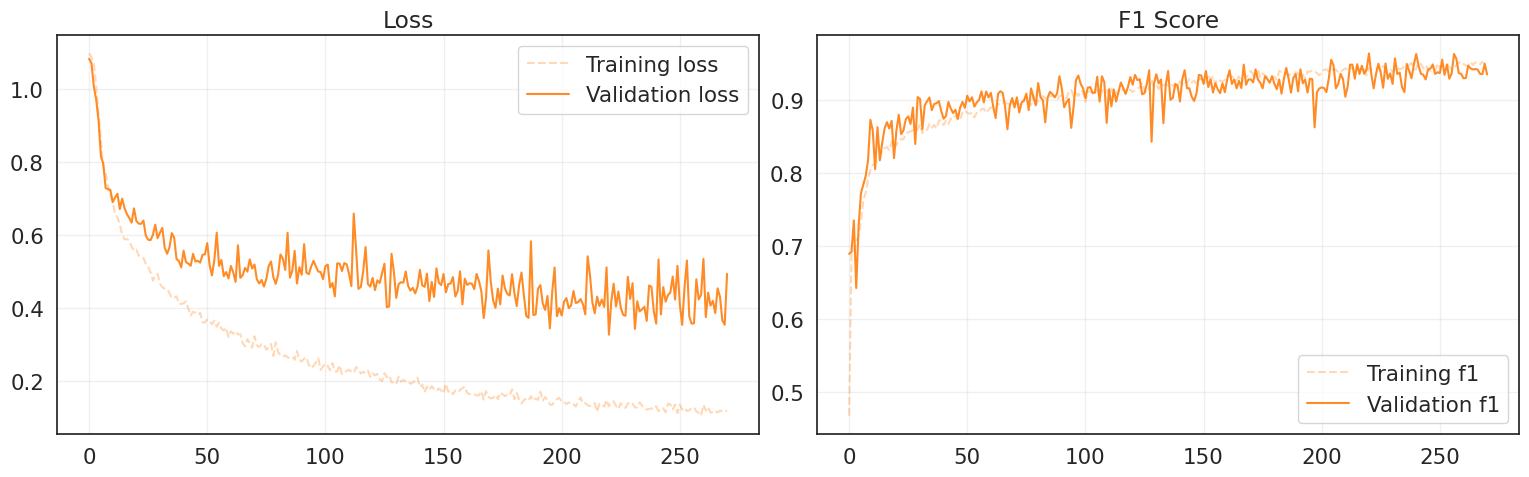

In [ ]:
# @title Plot Hitory - bi-LSTM
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9375
Precision over the validation set: 0.9453
Recall over the validation set: 0.9375
F1 score over the validation set: 0.9398


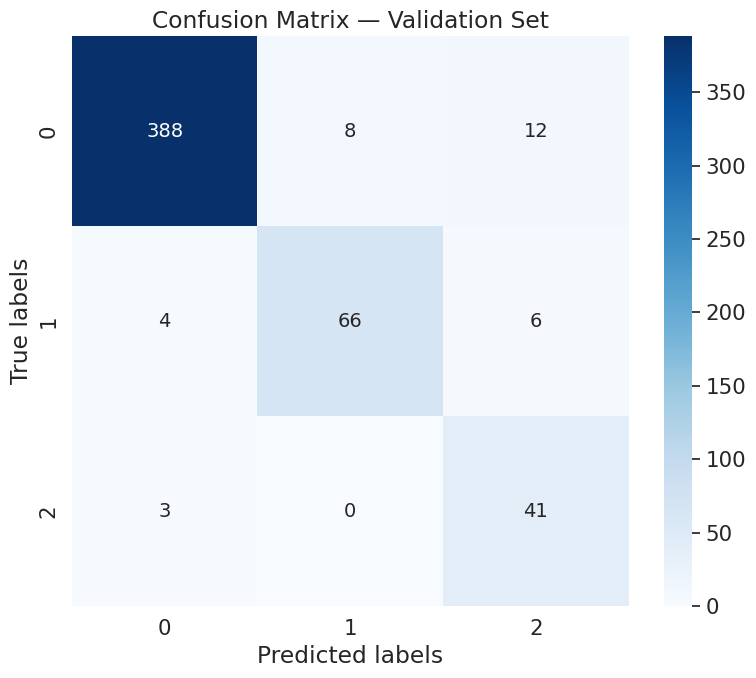

In [ ]:
# @title Plot Confusion Matrix - LSTM
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb_seq, xb_static, yb, _ in val_loader:
        xb_seq, xb_static = xb_seq.to(device), xb_static.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb_seq, xb_static)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## ** **Test** ** ##

In [ ]:
# Regenerate sequences for the test set using the modified function
X_test_seq, X_test_static, y_test, test_sequence_sample_indices = build_sequences_with_indices(dft, WINDOW_SIZE, STRIDE)

# Convert the test dataset to a TensorDataset
test_ds_with_indices = TensorDataset(torch.from_numpy(X_test_seq), torch.from_numpy(X_test_static), torch.from_numpy(y_test))

# Create a DataLoader for the test set (without shuffling)
test_loader_with_indices = make_loader(test_ds_with_indices, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of X_test_static: {X_test_static.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Shape of test_sequence_sample_indices: {test_sequence_sample_indices.shape}")

Shape of X_test_seq: (17212, 40, 34)
Shape of X_test_static: (17212, 2)
Shape of y_test: (17212,)
Shape of test_sequence_sample_indices: (17212,)


In [ ]:
best_model.eval() # Set the model to evaluation mode

all_logits_list = [] # To store all logits
all_sample_indices_list = [] # To store corresponding sample_indices

with torch.no_grad():
    for i, (xb_seq, xb_static, _) in enumerate(test_loader_with_indices):
        xb_seq, xb_static = xb_seq.to(device), xb_static.to(device)

        # Forward pass: get model logits
        logits = best_model(xb_seq, xb_static)

        # Apply softmax to get probabilities
        probabilities = torch.nn.functional.softmax(logits, dim=1)

        # Store probabilities and corresponding sample indices
        all_logits_list.append(probabilities.cpu().numpy())

        # Get the sample_indices for this batch directly from the pre-generated array
        batch_size = xb_seq.size(0)
        start_idx = i * BATCH_SIZE
        end_idx = start_idx + batch_size
        all_sample_indices_list.append(test_sequence_sample_indices[start_idx:end_idx])

# Concatenate all collected data
all_probabilities = np.concatenate(all_logits_list)
all_collected_sample_indices = np.concatenate(all_sample_indices_list)

# Create a DataFrame to easily group by sample_index
prediction_df = pd.DataFrame({
    'sample_index': all_collected_sample_indices,
    'probabilities': list(all_probabilities) # Store probabilities as list in DataFrame
})

# Group by sample_index and average the probabilities for each user
user_level_df = prediction_df.groupby('sample_index').agg(
    avg_probabilities=('probabilities', lambda x: np.mean(np.array(list(x)), axis=0))
).reset_index()

# Determine the predicted label by taking the argmax of the averaged probabilities
user_level_df['predicted_label'] = np.argmax(np.array(list(user_level_df['avg_probabilities'])), axis=1)

print("Predicted labels for each user in the test set (first 10):")
display(user_level_df.head(10))

# The subsequent cells will use `user_level_df` instead of `user_predictions`

Predicted labels for each user in the test set (first 10):


,sample_index,avg_probabilities,predicted_label
0,0,"[0.99800515, 8.102338e-06, 0.0019868102]",0
1,1,"[0.992363, 0.007528734, 0.000108288514]",0
2,2,"[0.99829966, 3.693838e-05, 0.0016633848]",0
3,3,"[0.7963931, 0.0008368383, 0.20277008]",0
4,4,"[0.99908704, 2.7967551e-05, 0.00088501547]",0
5,5,"[0.6945189, 0.0012647108, 0.30421638]",0
6,6,"[0.87686783, 0.00012470374, 0.12300747]",0
7,7,"[0.997549, 0.0024412272, 9.786916e-06]",0
8,8,"[0.7581786, 0.000570489, 0.24125093]",0
9,9,"[0.9991252, 9.04089e-05, 0.0007844565]",0


In [ ]:
# Create an inverse mapping from integer labels back to string labels
inverse_label_mapping_pain = {v: k for k, v in label_mapping_pain.items()}

# Map the predicted integer labels back to string labels
user_level_df['predicted_label_str'] = user_level_df['predicted_label'].map(inverse_label_mapping_pain)

# Display the first few rows with the string labels
print("Predicted labels with original names:")
display(user_level_df.head())

Predicted labels with original names:


,sample_index,avg_probabilities,predicted_label,predicted_label_str
0,0,"[0.99800515, 8.102338e-06, 0.0019868102]",0,no_pain
1,1,"[0.992363, 0.007528734, 0.000108288514]",0,no_pain
2,2,"[0.99829966, 3.693838e-05, 0.0016633848]",0,no_pain
3,3,"[0.7963931, 0.0008368383, 0.20277008]",0,no_pain
4,4,"[0.99908704, 2.7967551e-05, 0.00088501547]",0,no_pain


In [ ]:
# Select only the sample_index and the new string label column
output_df = user_level_df[['sample_index', 'predicted_label_str']]

# Rename the predicted_label_str column to label
output_df = output_df.rename(columns={'predicted_label_str': 'label'})

# Define the output CSV file path
output_csv_path = 'test_user_predictions.csv'

# Save the DataFrame to a CSV file
output_df.to_csv(output_csv_path, index=False)

print(f"\nPredicted user labels saved to {output_csv_path}")


Predicted user labels saved to test_user_predictions.csv
